In [91]:
import sys
import torch
import math
from xray_gaussian_rasterization_voxelization import (
    GaussianRasterizationSettings,
    GaussianRasterizer,
    GaussianVoxelizationSettings,
    GaussianVoxelizer,
)

sys.path.append("./")
from r2_gaussian.gaussian.gaussian_model import GaussianModel
from r2_gaussian.dataset.cameras import Camera
from r2_gaussian.arguments import PipelineParams

In [6]:
from r2_gaussian.dataset import Scene
from r2_gaussian.gaussian import GaussianModel, render, query, initialize_gaussian

In [7]:
from argparse import ArgumentParser
from r2_gaussian.arguments import (
    ModelParams,
    PipelineParams,
    get_combined_args,
)

In [8]:
from argparse import Namespace

In [ ]:
parser = ArgumentParser(description="Testing script parameters")
model = ModelParams(parser, sentinel=True)

pipeline = PipelineParams(parser)


# Namespace で引数を手動指定
args = Namespace(
    source_path="/home/maemaeko/imari_lab/r2_gaussian/data/real_dataset/cone_ntrain_75_angle_360/teapot",
    #model_path="/home/maemaeko/imari_lab/r2_gaussian/output/synthetic_dataset/cone_ntrain_9_angle_360-wo-densification/2_teapot_cone",
    model_path="/home/maemaeko/imari_lab/r2_gaussian/output/synthetic_dataset/cone_ntrain_9_angle_360-wo-densification/2_teapot_cone",
    data_device="cuda",
    scale_min=0.0005,
    scale_max=0.5,
    eval=True
)

dataset = model.extract(args)
scene = Scene(
    dataset,
    shuffle=False
)

Reading camera 75/75 for train
Reading camera 100/100 for test
Loading Training Cameras
Loading Test Cameras


In [120]:
# Set up Gaussians
gaussians = GaussianModel(None)  # scale_bound will be loaded later
loaded_iter = initialize_gaussian(gaussians, dataset, -1)
scene.gaussians = gaussians

Loading trained model at iteration 10000
Loading from /home/maemaeko/imari_lab/r2_gaussian/output/synthetic_dataset/cone_ntrain_9_angle_360-wo-densification/2_teapot_cone/point_cloud/iteration_10000/point_cloud.pickle


In [121]:
import torch

def quat_to_rotmat(q: torch.Tensor) -> torch.Tensor:
    """
    q: (..., 4)  [r, x, y, z]
    return: (..., 3, 3)
    """
    r, x, y, z = q.unbind(-1)
    # 3DGS の computeCov3D に合わせた回転
    R = torch.stack([
        1 - 2*(y*y + z*z),  2*(x*y - r*z),      2*(x*z + r*y),
        2*(x*y + r*z),      1 - 2*(x*x + z*z),  2*(y*z - r*x),
        2*(x*z - r*y),      2*(y*z + r*x),      1 - 2*(x*x + y*y),
    ], dim=-1)
    R = R.reshape(q.shape[:-1] + (3, 3))
    return R


def build_cov3d(scale: torch.Tensor,
                rot: torch.Tensor,
                scale_modifier: float = 1.0) -> torch.Tensor:
    """
    scale: (N,3)
    rot:   (N,4) quaternion [r,x,y,z]
    return: Sigma: (N,3,3)  3D 共分散行列
    """
    # S 行列
    s = scale_modifier * scale
    S = torch.zeros(scale.shape[0], 3, 3, device=scale.device, dtype=scale.dtype)
    S[:, 0, 0] = s[:, 0]
    S[:, 1, 1] = s[:, 1]
    S[:, 2, 2] = s[:, 2]

    # 回転行列
    R = quat_to_rotmat(rot)

    # M = S * R
    M = torch.matmul(S, R)

    # Sigma = M^T * M
    Sigma = torch.matmul(M.transpose(-1, -2), M)
    return Sigma


In [122]:


def gaussian_density_along_ray(
    ray_o: torch.Tensor,          # (3,)
    ray_d: torch.Tensor,          # (3,), normalized
    t_vals: torch.Tensor,         # (S,)
    xyz: torch.Tensor,            # (N,3)
    Sigma: torch.Tensor,          # (N,3,3)
    opacity: torch.Tensor,        # (N,)
    line_radius: float = None,    # None or 距離閾値 (optional)
) -> torch.Tensor:
    """
    与えられた Gaussians に対し、1本の ray 上のサンプル点での密度 ρ(t) を計算する。

    return: rho: (S,)  ray 上の密度プロファイル
    """
    device = xyz.device
    ray_o = ray_o.to(device)
    ray_d = ray_d.to(device)
    t_vals = t_vals.to(device)
    opacity = opacity.to(device)
    Sigma = Sigma.to(device)

    # まず、この ray に関係しそうな Gaussian だけに絞る（optional）
    idx = torch.arange(xyz.shape[0], device=device)
    if line_radius is not None:
        # 線分と点の距離: || (p - o) x d || / ||d||
        # ここでは d は正規化前提として ||d||=1 でOK
        v = xyz - ray_o[None, :]          # (N,3)
        cross = torch.cross(v, ray_d[None, :].expand_as(v), dim=-1)
        dist_line = cross.norm(dim=-1)    # (N,)
        mask = dist_line <= line_radius
        idx = idx[mask]

    if idx.numel() == 0:
        return torch.zeros_like(t_vals)

    # フィルタされた Gaussians
    mu = xyz[idx]          # (M,3)
    Sig = Sigma[idx]       # (M,3,3)
    opa = opacity[idx]     # (M,)

    # 逆行列を計算
    Sig_inv = torch.inverse(Sig)  # (M,3,3)

    # ray 上サンプル点
    # x(t_k) = o + t_k d
    pts = ray_o[None, :] + t_vals[:, None] * ray_d[None, :]   # (S,3)

    # (M,S,3) にブロードキャスト
    diff = pts[None, :, :] - mu[:, None, :]   # (M,S,3)

    # diff^T * Sig_inv * diff を計算： (M,S)
    # tmp = diff @ Sig_inv
    tmp = torch.matmul(diff, Sig_inv)    # (M,S,3)
    maha = (tmp * diff).sum(dim=-1)      # (M,S)

    # ガウシアン値（正規化定数無視）
    gauss_val = torch.exp(-0.5 * maha)   # (M,S)

    # opacity で重み付け
    rho = (opa[:, None] * gauss_val).sum(dim=0)  # (S,)

    return rho


In [123]:
def compute_ray_boundary(
    ray_o: torch.Tensor,
    ray_d: torch.Tensor,
    t_vals: torch.Tensor,
    xyz: torch.Tensor,
    Sigma: torch.Tensor,
    opacity: torch.Tensor,
    line_radius: float = None,
):
    """
    1本の ray について:
    - density profile ρ(t)
    - 差分 |ρ(t_k) - ρ(t_{k-1})|
    - 最大変化位置（boundary 候補）

    を返す。
    """
    # ρ(t) プロファイル
    rho = gaussian_density_along_ray(
        ray_o, ray_d, t_vals, xyz, Sigma, opacity, line_radius=line_radius
    )  # (S,)

    # 差分（前向き or 後向きどちらでも良いが、ここでは後ろとの差分）
    diff = torch.zeros_like(rho)
    diff[1:] = (rho[1:] - rho[:-1]).abs()

    # 一番大きい差分 = boundary 候補
    max_idx = torch.argmax(diff)
    max_t = t_vals[max_idx]
    max_grad = diff[max_idx]

    result = {
        "t_vals": t_vals,     # (S,)
        "rho": rho,           # (S,)
        "grad": diff,         # (S,)
        "boundary_index": max_idx.item(),
        "boundary_t": max_t.item(),
        "boundary_strength": max_grad.item(),
    }
    return result


Loading trained model at iteration 10000
Loading from /home/maemaeko/imari_lab/r2_gaussian/output/synthetic_dataset/cone_ntrain_9_angle_360-wo-densification/2_teapot_cone/point_cloud/iteration_10000/point_cloud.pickle


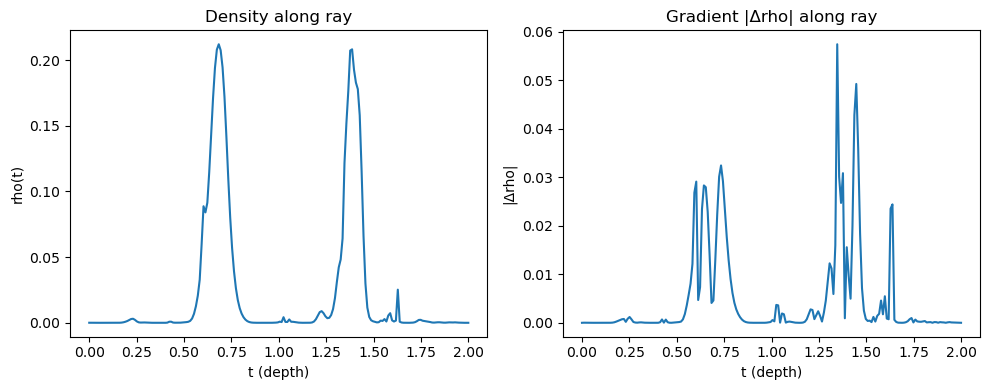

Boundary t: 1.3467336893081665
Boundary strength: 0.057414814829826355


In [124]:
import torch
import matplotlib.pyplot as plt

# デバイス
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 適当な Gaussians を N=200 個作る（テスト用）
# N = 200
# xyz = torch.randn(N, 3, device=device) * 0.1 + torch.tensor([[0.0, 0.0, 1.0]], device=device)  # 奥行き1m付近
# scale = torch.full((N,3), 0.02, device=device)  # 半径2cmくらい
# rot = torch.randn(N, 4, device=device)
# rot = rot / rot.norm(dim=-1, keepdim=True)
# opacity = torch.rand(N, device=device) * 1.0  # 適当

gaussians = GaussianModel(None)
loaded_iter = initialize_gaussian(gaussians, dataset, -1)


xyz     = gaussians.get_xyz[:, :3]
scale  = gaussians.get_scaling[:, :3]
opacity = gaussians.get_density[:, 0]
rot = gaussians.get_rotation[:, :4]


# 共分散を作る
Sigma = build_cov3d(scale, rot, scale_modifier=1.0)

# ray の設定（原点から z方向に伸びる ray）
ray_o = torch.tensor([-1.0, 0.5, 0], device=device)
ray_d = torch.tensor([1, 0.0, 0], device=device)
ray_d = ray_d / ray_d.norm()

# 深さサンプル t（0.0 ~ 2.0 m の間を 200 分割）
t_vals = torch.linspace(0.0, 2.0, steps=200, device=device)

# line_radius は、ray からの距離で Gaussians を cull する半径（例: 5cm）
res = compute_ray_boundary(
    ray_o, ray_d, t_vals,
    xyz, Sigma, opacity,
    line_radius=0.05
)

# 可視化
t_cpu = res["t_vals"].detach().cpu().numpy()
rho_cpu = res["rho"].detach().cpu().numpy()
grad_cpu = res["grad"].detach().cpu().numpy()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Density along ray")
plt.plot(t_cpu, rho_cpu)
plt.xlabel("t (depth)")
plt.ylabel("rho(t)")

plt.subplot(1,2,2)
plt.title("Gradient |Δrho| along ray")
plt.plot(t_cpu, grad_cpu)
plt.xlabel("t (depth)")
plt.ylabel("|Δrho|")

plt.tight_layout()
plt.show()

print("Boundary t:", res["boundary_t"])
print("Boundary strength:", res["boundary_strength"])


In [125]:
# ---- ここから追加 ----
grad = res["grad"]      # (S,)
t_vals_tensor = res["t_vals"]  # (S,)

k = 10  # 上位いくつ取りたいか

# 勾配が大きい順に top-k を取得
top_vals, top_idx = torch.topk(grad, k=k)   # どちらも shape=(k,)

top_t = t_vals_tensor[top_idx]              # 対応する t 値

print("Top-3 gradient peaks:")
for i in range(k):
    print(f"{i+1}: t = {top_t[i].item():.4f}, |Δrho| = {top_vals[i].item():.4f}")

Top-3 gradient peaks:
1: t = 1.3467, |Δrho| = 0.0574
2: t = 1.4472, |Δrho| = 0.0492
3: t = 1.4372, |Δrho| = 0.0428
4: t = 1.4573, |Δrho| = 0.0360
5: t = 0.7337, |Δrho| = 0.0324
6: t = 1.3769, |Δrho| = 0.0308
7: t = 1.3568, |Δrho| = 0.0301
8: t = 0.7236, |Δrho| = 0.0301
9: t = 0.7437, |Δrho| = 0.0292
10: t = 0.6030, |Δrho| = 0.0291


In [126]:
import torch
import numpy as np

def fov_to_focal(FoVx, FoVy, W, H):
    fx = W / (2.0 * np.tan(FoVx / 2.0))
    fy = H / (2.0 * np.tan(FoVy / 2.0))
    return fx, fy


def generate_rays_from_camera_obj(camera, device=None):
    """
    Camera クラスのインスタンスから、
    各ピクセルの ray origin & direction を world 座標で生成する。
    """
    if device is None:
        device = camera.world_view_transform.device

    H = camera.image_height
    W = camera.image_width

    # --- c2w を取得（world_view_transform: world→view の逆）---
    w2c = camera.world_view_transform.inverse().to(device)  # (4,4)
    #print(w2c)

    # c2w = np.eye(4, dtype=np.float32)
    # c2w[:3, :3] = camera.R
    # c2w[:3, 3] = camera.camera_center.cpu()

    # c2w = torch.from_numpy(c2w).to(device)


    # --- FoV から fx, fy 計算 ---
    fx, fy = fov_to_focal(camera.FoVx, camera.FoVy, W, H)
    cx = W / 2.0
    cy = H / 2.0

    # --- ピクセルグリッド ---
    i, j = torch.meshgrid(
        torch.arange(W, device=device),
        torch.arange(H, device=device),
        indexing="xy"
    )  # i: x, j: y

    # カメラ座標系での方向 (z+ 向き)
    x_cam = (i - cx) / fx
    y_cam = (j - cy) / fy
    z_cam = torch.ones_like(x_cam)

    dirs_cam = torch.stack([x_cam, y_cam, z_cam], dim=-1)  # (H,W,3)
    dirs_cam = dirs_cam / torch.norm(dirs_cam, dim=-1, keepdim=True)

    # --- camera → world ---
    # R_w2c を float32 でテンソル化
    R_w2c = torch.tensor(camera.R.T, device=device, dtype=torch.float32)
    T_w2c = torch.tensor(camera.T, device=device, dtype=torch.float32)

    # camera → world
    R_c2w = R_w2c.t()                      # (3,3)
    T_c2w = camera.camera_center.to(device, dtype=torch.float32)

    # dirs_cam は (H,W,3) float32 のまま

    # dirs_cam → dirs_world
    dirs_world = torch.matmul(dirs_cam, R_c2w.T)  # float32 × float32 = OK
    dirs_world = dirs_world / torch.norm(dirs_world, dim=-1, keepdim=True)

    # origins
    origins_world = T_c2w.view(1,1,3).expand(H, W, 3)


    return origins_world, dirs_world


In [127]:
def depth_map_from_camera_obj(
    camera,
    xyz, Sigma, opacity,
    t_near: float, t_far: float,
    n_samples: int = 128,
    line_radius: float = None,
    device=None,
):
    """
    1つの Camera から boundary depth map を計算。
    - depth_map[y,x]      = 境界の t
    - strength_map[y,x]   = |Δrho| の最大値
    """
    if device is None:
        device = xyz.device

    xyz     = xyz.to(device)
    Sigma   = Sigma.to(device)
    opacity = opacity.to(device)

    H = camera.image_height
    W = camera.image_width

    # --- 各ピクセルの ray を生成 ---
    origins, dirs = generate_rays_from_camera_obj(camera, device=device)  # (H,W,3)

    # --- t サンプル ---
    t_vals = torch.linspace(t_near, t_far, steps=n_samples, device=device)

    depth_map    = torch.zeros(H, W, device=device)
    strength_map = torch.zeros(H, W, device=device)

    # 解析用なのでまずは素直な2重ループ（解像度は小さめ推奨）
    for y in range(H):
        for x in range(W):
            ray_o = origins[y, x]  # (3,)
            ray_d = dirs[y, x]     # (3,)

            res = compute_ray_boundary(
                ray_o, ray_d, t_vals,
                xyz, Sigma, opacity,
                line_radius=line_radius,
            )

            depth_map[y, x]    = res["boundary_t"]
            strength_map[y, x] = res["boundary_strength"]
    # depth_map, strength_map を作り終わったあとに追加
    threshold = 0.03     # 好きなしきい値（例）
    invalid_value = 0.0  # depth を入れない場所につける値（NaN でも OK）

    mask = (strength_map < threshold)
    depth_map[mask] = invalid_value

    

    return depth_map, strength_map, t_vals


In [130]:
# Gaussians を PyTorch に取り出す（() を忘れずに）
gaussians = GaussianModel(None)
loaded_iter = initialize_gaussian(gaussians, dataset, -1)

xyz     = xyz.to(device)
scale   = scale.to(device)
opacity = opacity.to(device)
rot     = rot.to(device)

Sigma = build_cov3d(scale, rot, scale_modifier=1.0)

# カメラを軌道上に生成
cams = scene.getTrainCameras()

all_depth_maps    = []
all_strength_maps = []

#t_near, t_far = 4.5, 5.5  # カメラ半径5.0を想定した例
t_near, t_far = 4, 4.5
n_samples = 128

for cam in cams[:1]:
    depth_map, strength_map, t_vals = depth_map_from_camera_obj(
        cam,
        xyz, Sigma, opacity,
        t_near, t_far,
        n_samples=n_samples,
        line_radius=0.1,   # ray から10cm以内の Gaussian のみ考える
        device=device,
    )
    all_depth_maps.append(depth_map.cpu())
    all_strength_maps.append(strength_map.cpu())


Loading trained model at iteration 10000
Loading from /home/maemaeko/imari_lab/r2_gaussian/output/synthetic_dataset/cone_ntrain_9_angle_360-wo-densification/2_teapot_cone/point_cloud/iteration_10000/point_cloud.pickle


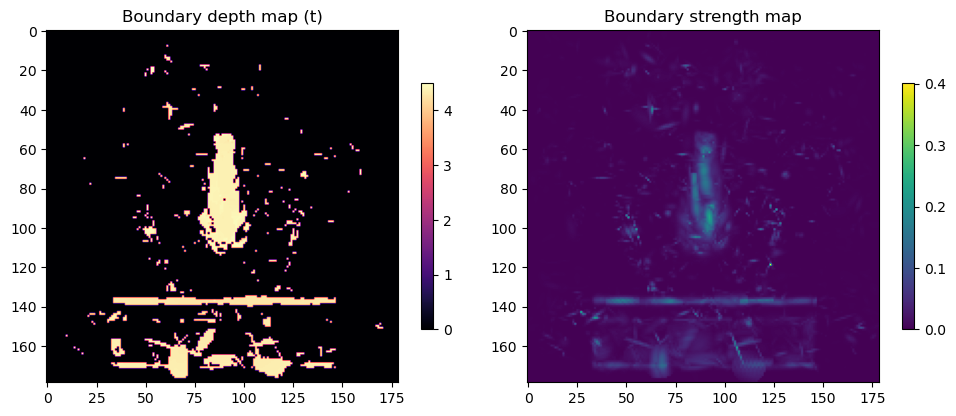

In [131]:
import matplotlib.pyplot as plt

depth = all_depth_maps[0].numpy()
strength = all_strength_maps[0].numpy()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Boundary depth map (t)")
im1 = plt.imshow(depth, cmap="magma")
plt.colorbar(im1, shrink=0.7)

plt.subplot(1,2,2)
plt.title("Boundary strength map")
im2 = plt.imshow(strength, cmap="viridis")
plt.colorbar(im2, shrink=0.7)

plt.tight_layout()
plt.show()